# MP2.5 y urgencias respiratorias — Santiago, Talcahuano y Coyhaique

**Asociación, nunca causalidad.** Diseño ecológico observacional sobre datos
agregados a ciudad-día. Ninguna fila describe a una persona, y ningún resultado
de este cuaderno permite afirmar que la contaminación *causa* consultas.

---

## Hipótesis primaria, fijada antes de correr nada

Seis causas × ocho rezagos × tres ciudades son 144 estimaciones: con eso siempre
sale algo significativo. Para que el resultado signifique algo, **una sola** queda
declarada como principal y todo lo demás se rotula como exploratorio.

| | |
|---|---|
| **Desenlace** | `resp` — total del sistema respiratorio (J00-J98), `IdCausa = 2` |
| **Exposición** | `mp25_ma03` — media móvil de 3 días |
| **Ventana** | **2022-2024** — sin COVID y con cobertura de temperatura completa |
| **Modelo** | case-crossover estratificado; estratos ciudad × año × mes × día-semana |
| **Medida** | RR por cada 10 µg/m³, IC 95 % |
| **Control negativo** | `trauma` (IdCausa 18) **y** `transito` (IdCausa 19), en toda especificación |

**Regla de parada, declarada de antemano:** si el control negativo sale
significativo en la especificación final, el resultado principal **no se reporta
como asociación limpia**.

## Preparación

Rutas relativas y semilla fija. La maquinaria vive en `src/analisis/asociacion.py`
para que este cuaderno sea narrativa y no andamiaje.

In [1]:
import sys
import time
import warnings
from pathlib import Path

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ))
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.analisis import asociacion as A

np.random.seed(A.SEMILLA)
pd.set_option("display.width", 190)

# Un color por rol: exposición, desenlace, control negativo. Paleta validada
# con el verificador de daltonismo: ΔE 17,4 en protanopia, 25,9 en visión normal.
C_MP25, C_URG, C_NEG = "#A96A00", "#1F6FB2", "#B0324A"
CIUDADES = ["santiago", "talcahuano", "coyhaique"]
COLOR_CIUDAD = dict(zip(CIUDADES, [C_MP25, C_URG, C_NEG]))
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": .25,
                     "font.size": 9, "axes.spines.top": False,
                     "axes.spines.right": False})
print("semilla", A.SEMILLA, "· raíz", RAIZ.name)

semilla 20260829 · raíz Big_Data_proj


---
## Fase 0 — QA y perfilado

**Pregunta:** ¿qué años y ciudades soportan un modelo, y qué hay que arreglar antes?

### 0.1 · Los esquemas reales, no los supuestos

In [2]:
import pyarrow.parquet as pq

PROC = RAIZ / "data" / "processed"
for carpeta in sorted(PROC.iterdir()):
    archivos = sorted(carpeta.rglob("*.parquet")) if carpeta.is_dir() else []
    if not archivos:
        continue
    n = sum(pq.ParquetFile(f).metadata.num_rows for f in archivos)
    print(f"{carpeta.name:<26}{n:>12,} filas  {len(archivos):>2} archivo(s)")

analitico_ciudad_semana          1,350 filas   1 archivo(s)
dim_causa                           41 filas   1 archivo(s)
dim_ciudad                           3 filas   1 archivo(s)
dim_establecimiento                818 filas   1 archivo(s)
dim_estacion                        21 filas   1 archivo(s)
dim_tiempo                       3,156 filas   1 archivo(s)
hecho_medicion               4,133,913 filas   9 archivo(s)
hecho_urgencia              66,305,151 filas   9 archivo(s)
poblacion_ciudad_anio               27 filas   1 archivo(s)
poblacion_comuna_anio            3,114 filas   1 archivo(s)


### 0.2 · Un establecimiento renumerado que rompería el panel

Buscando nombres repetidos en la misma comuna con rangos de fecha disjuntos
aparece **un** caso: `SAR Los Cerros`, en Talcahuano, cambió de identificador el
1 de enero de 2024 con **cero días de solape**.

Importa porque el panel equilibrado exige reportar ≥95 % de los días: sin
fusionar, el mismo recinto figura como dos que reportan la mitad del tiempo cada
uno y **se descarta dos veces**.

In [3]:
urg_todas = A.leer_urgencias([A.CAUSA_TOTAL, A.CAUSA_RESP_TOTAL, A.CAUSA_TRAUMA,
                              A.CAUSA_TRANSITO, *A.CAUSAS_RESP])
base = urg_todas[urg_todas.causa_id == A.CAUSA_TOTAL]
for eid in ["19-912", "201018"]:
    g = base[base.establecimiento_id == eid]
    print(f"{eid:<8} {g.fecha.min():%Y-%m-%d} .. {g.fecha.max():%Y-%m-%d}"
          f"  {g.fecha.nunique():>5} días")

f1 = set(base[base.establecimiento_id == "19-912"].fecha)
f2 = set(base[base.establecimiento_id == "201018"].fecha)
veredicto = "mismo recinto renumerado" if not (f1 & f2) else "coexisten"
print(f"días en común: {len(f1 & f2)}  ->  {veredicto}")
print(f"fusión aplicada: {A.RENUMERADOS}")

19-912   2021-03-01 .. 2023-12-31   1036 días
201018   2024-01-01 .. 2026-08-23    959 días
días en común: 0  ->  mismo recinto renumerado
fusión aplicada: {'201018': '19-912'}


### 0.3 · Construcción del panel ciudad-día

Incluye la limpieza de temperatura —rango físico [−25, 40] °C y descarte por
desviación mayor a 10 °C contra la mediana móvil de 11 horas—, reimplementada
aquí para que el cuaderno no dependa de un archivo limpiado a mano fuera del
repositorio.

In [4]:
t0 = time.time()
panel = A.panel_ciudad_dia()
print("limpieza de temperatura:", panel.attrs["informe_temperatura"])

esperadas = 3 * 3156
estado = "OK" if len(panel) == esperadas else "<< NO CALZA"
print(f"\nfilas: {len(panel):,}   esperadas: {esperadas:,}   {estado}")
print(f"duplicados (ciudad,fecha): {panel.duplicated(['ciudad_id', 'fecha']).sum()}")
print(f"rango: {panel.fecha.min():%Y-%m-%d} .. {panel.fecha.max():%Y-%m-%d}")
print("\nnulos:")
for c in ["mp25", "temp", "humedad", "viento_vel", "viento_persistencia"]:
    print(f"  {c:<22}{panel[c].isna().sum():>6}")
print(f"\n({time.time() - t0:.0f} s)")

limpieza de temperatura: {'horas_iniciales': 732713, 'fuera_de_rango': 0, 'desviacion_excesiva': 27, 'horas_finales': 732686}

filas: 9,468   esperadas: 9,468   OK
duplicados (ciudad,fecha): 0
rango: 2018-01-01 .. 2026-08-22

nulos:
  mp25                       0
  temp                     412
  humedad                  413
  viento_vel               140
  viento_persistencia      140

(9 s)


### 0.4 · Panel equilibrado de establecimientos

El número de establecimientos que reportan cambia con el tiempo —Santiago pasa de
88 en 2018 a 116 en 2026— y también **dentro** de un mismo mes. Días con más
establecimientos tienen más de *todo*, traumatismos incluidos, y los estratos
año×mes×día-semana no absorben esa variación intramensual.

Se restringe a los que reportan ≥95 % de los días. Restringir es preferible a un
offset por número de reportantes: el offset asume proporcionalidad, esto elimina
el problema en el origen.

In [5]:
VENT_INI, VENT_FIN = "2022-01-01", "2026-08-22"
retenidos, cobertura = A.panel_equilibrado(urg_todas, VENT_INI, VENT_FIN)
print(cobertura.groupby("ciudad_id").retenido.agg(retenidos="sum", total="size").to_string())

resp_v = urg_todas[(urg_todas.fecha >= VENT_INI)
                   & (urg_todas.causa_id == A.CAUSA_RESP_TOTAL)]
print("\n% de urgencias respiratorias que sobrevive al equilibrado:")
for c, g in resp_v.groupby("ciudad_id"):
    pct = 100 * g[g.id_fusionado.isin(retenidos)].total.sum() / g.total.sum()
    print(f"  {c:<11}{pct:>6.1f} %")

d = A.agregar_desenlaces(panel, urg_todas, retenidos)
d = d.sort_values(["ciudad_id", "fecha"]).reset_index(drop=True)
print(f"\npanel con desenlaces: {d.shape}")

            retenidos  total
ciudad_id                   
coyhaique           2      2
santiago          107    122
talcahuano          5      6

% de urgencias respiratorias que sobrevive al equilibrado:
  coyhaique   100.0 %
  santiago     94.5 %
  talcahuano   99.6 %

panel con desenlaces: (9468, 39)


> **Lectura.** Con la fusión del renumerado, Talcahuano retiene el 99,6 % de sus
> urgencias respiratorias en vez del 82,5 % que perdía tratándolo como dos
> establecimientos. Sin ese arreglo, el equilibrado habría descartado de forma
> selectiva un recinto entero — que era justo el riesgo a verificar.

### 0.5 · El faltante de temperatura **no es aleatorio**

La red meteorológica de Santiago dejó de publicar el 8 de mayo de 2025 a las
11:00 —seis estaciones, el mismo minuto— mientras el MP2.5 de esas mismas
estaciones siguió sin cortarse. Ese corte cae justo al inicio de la temporada
alta de material particulado.

Si el faltante correlaciona con la exposición, el caso completo borra
sistemáticamente los días más contaminados. Hay que medirlo, no suponerlo.

In [6]:
d["sin_temp"] = d.temp.isna()
print(f"días-ciudad sin temperatura: {int(d.sin_temp.sum())} de {len(d)}"
      f" ({100 * d.sin_temp.mean():.1f} %)\n")
print("MP2.5 medio en días CON vs SIN temperatura:")
for c, g in d.groupby("ciudad_id"):
    if g.sin_temp.sum() == 0:
        print(f"  {c:<11} sin faltantes")
        continue
    con = g.loc[~g.sin_temp, "mp25"].mean()
    sin = g.loc[g.sin_temp, "mp25"].mean()
    print(f"  {c:<11} con {con:>5.1f}   sin {sin:>5.1f}   "
          f"razón {sin / con:>4.2f}x   (n={int(g.sin_temp.sum())})")

print("\nfaltantes por mes:")
print(d[d.sin_temp].pivot_table(index="mes", columns="ciudad_id", values="fecha",
                                aggfunc="count", fill_value=0).to_string())
print("\ncobertura por ventana de modelado:")
for etq, a, b in [("2022-2024", 2022, 2024), ("2025-2026", 2025, 2026)]:
    g = d[d.anio.between(a, b)]
    print(f"  {etq}: {len(g):>5} días-ciudad · sin temp "
          f"{int(g.sin_temp.sum()):>4} ({100 * g.sin_temp.mean():.1f} %)")

días-ciudad sin temperatura: 412 de 9468 (4.4 %)

MP2.5 medio en días CON vs SIN temperatura:
  coyhaique   con  41.4   sin  39.3   razón 0.95x   (n=1)
  santiago    con  23.3   sin  34.5   razón 1.48x   (n=134)
  talcahuano  con  19.2   sin  25.2   razón 1.31x   (n=277)

faltantes por mes:
ciudad_id  coyhaique  santiago  talcahuano
mes                                       
1                  0         0          37
2                  0         1          32
3                  0         0          32
4                  0         0          34
5                  0        24          31
6                  0        30          30
7                  1        32          32
8                  0        19          28
9                  0         0          10
10                 0         3           2
11                 0        25           6
12                 0         0           3

cobertura por ventana de modelado:
  2022-2024:  3288 días-ciudad · sin temp   32 (1.0 %)
  2025-2026:  1

> **Lectura.** El faltante es informativo: los días sin temperatura tienen MP2.5
> más alto (Santiago 1,48×, Talcahuano 1,31×) y se concentran en mayo-agosto. No
> es faltante aleatorio, es faltante correlacionado con la exposición.
>
> Por eso el **modelo principal corre sobre 2022-2024**, donde el faltante es del
> 1,0 %, y 2025-2026 queda como sensibilidad. Si el coeficiente cambia entre
> ambas ventanas, el faltante está mordiendo.

### 0.6 · Qué años y ciudades quedan utilizables

In [7]:
res = d.groupby(["ciudad_id", "anio"]).agg(
    dias=("fecha", "size"), estab=("n_establecimientos", "median"),
    mp25=("mp25", "mean"), sin_temp=("sin_temp", "sum"),
    resp=("resp", "sum")).reset_index()
res["pct_sin_temp"] = (100 * res.sin_temp / res.dias).round(1)
res["usable"] = ((~res.anio.isin([2020, 2021])) & (res.pct_sin_temp < 5)
                 & (res.dias > 300))
print(res.pivot(index="anio", columns="ciudad_id", values="usable").to_string())
print()
print(res.round(1).to_string(index=False))

ciudad_id  coyhaique  santiago  talcahuano
anio                                      
2018            True      True       False
2019            True      True        True
2020           False     False       False
2021           False     False       False
2022            True      True        True
2023            True     False        True
2024            True      True        True
2025            True     False        True
2026           False     False       False

 ciudad_id  anio  dias  estab  mp25  sin_temp    resp  pct_sin_temp  usable
 coyhaique  2018   365    1.0  50.5         0   21719           0.0    True
 coyhaique  2019   365    1.0  40.0         0   20578           0.0    True
 coyhaique  2020   366    2.0  38.7         0    4388           0.0   False
 coyhaique  2021   365    2.0  35.5         0    4695           0.0   False
 coyhaique  2022   365    2.0  39.1         0   17147           0.0    True
 coyhaique  2023   365    2.0  37.1         0   21978           0.0   

> **Lectura.** 2020 y 2021 salen por la reorganización COVID **y** por el salto de
> 88 a 112 establecimientos en Santiago, que no revierte: los niveles de 2018-2019
> y de 2022+ no son comparables. 2026 es parcial (234 días). La ventana de
> modelado queda **2022-2024**.

### 0.7 · Variables derivadas y el proxy de temporada viral

**El proxy viral** usa la serie respiratoria de las *otras dos* ciudades,
estandarizada y suavizada a 7 días. La lógica: la epidemia de VRS es nacional y
sincrónica, mientras el MP2.5 es local y con calendarios distintos —Coyhaique
tiene su peak respiratorio en octubre y Santiago en invierno—, así que una ciudad
informa sobre la temporada viral de otra sin traer su contaminación.

**No es limpio y hay que decirlo:** si el MP2.5 correlaciona entre ciudades, el
proxy arrastra exposición y sesga hacia el nulo. El suavizado mitiga —la epidemia
es lenta, los picos de contaminación son rápidos— pero no elimina. Es un ajuste
**conservador**: si el coeficiente sobrevive es evidencia fuerte; si no, el
resultado es ambiguo entre confusión viral y sobreajuste.

In [8]:
gc = d.groupby("ciudad_id", group_keys=False)
for k in (1, 3, 7):
    d[f"mp25_ma{k:02d}"] = gc.mp25.apply(lambda s, k=k: s.rolling(k, min_periods=k).mean())
d["proxy_viral"] = A.proxy_viral(d)

corr = d.pivot_table(index="fecha", columns="ciudad_id", values="mp25")
corr = corr.loc["2022":"2024"].corr()
print("correlación del MP2.5 diario entre ciudades (2022-2024):")
print(corr.round(3).to_string())
fuera = corr.to_numpy()[~np.eye(3, dtype=bool)]
print(f"\nfuera de la diagonal: {fuera.min():.2f} a {fuera.max():.2f}")
print("cuanto más alta, más exposición arrastra el proxy -> sesgo hacia el nulo")

MODELO = d[d.anio.between(2022, 2024)].copy()
print(f"\nventana de modelado: {len(MODELO)} días-ciudad, "
      f"{MODELO.fecha.min():%Y-%m-%d} .. {MODELO.fecha.max():%Y-%m-%d}")

correlación del MP2.5 diario entre ciudades (2022-2024):
ciudad_id   coyhaique  santiago  talcahuano
ciudad_id                                  
coyhaique       1.000     0.481       0.509
santiago        0.481     1.000       0.555
talcahuano      0.509     0.555       1.000

fuera de la diagonal: 0.48 a 0.56
cuanto más alta, más exposición arrastra el proxy -> sesgo hacia el nulo

ventana de modelado: 3288 días-ciudad, 2022-01-01 .. 2024-12-31


---
## Fase 1 — Descriptivo del MP2.5

**Pregunta:** ¿cómo se comportan las tres ciudades, y son comparables entre sí?

In [9]:
NORMA_DIARIA = 50  # µg/m³, norma primaria chilena de MP2.5 en 24 h (D.S. 12/2011)

desc = d.groupby("ciudad_id").mp25.describe(percentiles=[.5, .95])
desc["dias_sobre_norma"] = d[d.mp25 > NORMA_DIARIA].groupby("ciudad_id").size()
desc["pct_sobre_norma"] = (100 * desc.dias_sobre_norma / desc["count"]).round(1)
print("MP2.5 diario, 2018-2026 (µg/m³)")
print(desc[["count", "mean", "50%", "95%", "max",
            "dias_sobre_norma", "pct_sobre_norma"]].round(1).to_string())

MP2.5 diario, 2018-2026 (µg/m³)
             count  mean   50%    95%    max  dias_sobre_norma  pct_sobre_norma
ciudad_id                                                                      
coyhaique   3156.0  41.4  21.2  141.9  474.2               820             26.0
santiago    3156.0  23.8  17.9   55.7   92.1               258              8.2
talcahuano  3156.0  19.7  12.5   59.2  159.2               246              7.8


### Estacionalidad y ciclo semanal

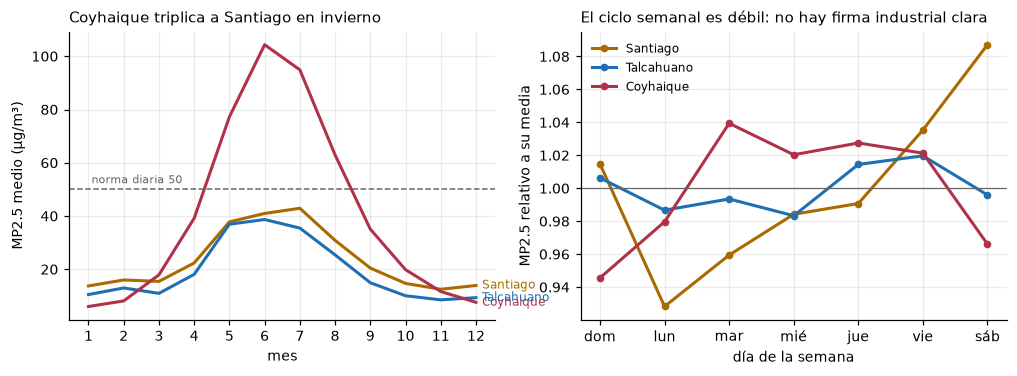

In [10]:
fig, ejes = plt.subplots(1, 2, figsize=(11, 3.4))

mensual = d.pivot_table(index=d.fecha.dt.month, columns="ciudad_id", values="mp25")
for c in CIUDADES:
    ejes[0].plot(mensual.index, mensual[c], color=COLOR_CIUDAD[c], lw=2, label=c.capitalize())
    ejes[0].annotate(c.capitalize(), (mensual.index[-1], mensual[c].iloc[-1]),
                     color=COLOR_CIUDAD[c], fontsize=8, xytext=(4, 0),
                     textcoords="offset points", va="center")
ejes[0].axhline(NORMA_DIARIA, color="#666", ls="--", lw=1)
ejes[0].annotate("norma diaria 50", (1, NORMA_DIARIA), fontsize=7, color="#666",
                 xytext=(2, 4), textcoords="offset points")
ejes[0].set_title("Coyhaique triplica a Santiago en invierno", loc="left", fontsize=10)
ejes[0].set_xlabel("mes")
ejes[0].set_ylabel("MP2.5 medio (µg/m³)")
ejes[0].set_xticks(range(1, 13))

semanal = d.pivot_table(index="dia_semana", columns="ciudad_id", values="mp25")
semanal = semanal / semanal.mean()
dias = ["dom", "lun", "mar", "mié", "jue", "vie", "sáb"]
for c in CIUDADES:
    ejes[1].plot(semanal.index, semanal[c], color=COLOR_CIUDAD[c], lw=2,
                 marker="o", ms=4, label=c.capitalize())
ejes[1].axhline(1, color="#666", lw=.8)
ejes[1].set_title("El ciclo semanal es débil: no hay firma industrial clara",
                  loc="left", fontsize=10)
ejes[1].set_xlabel("día de la semana")
ejes[1].set_ylabel("MP2.5 relativo a su media")
ejes[1].set_xticks(range(7))
ejes[1].set_xticklabels(dias)
ejes[1].legend(frameon=False, fontsize=8)
plt.show()

### Heatmap año × semana

Una fila por año, una columna por semana epidemiológica. Rampa de un solo tono,
claro a oscuro: la magnitud se lee por luminosidad, no por matiz.

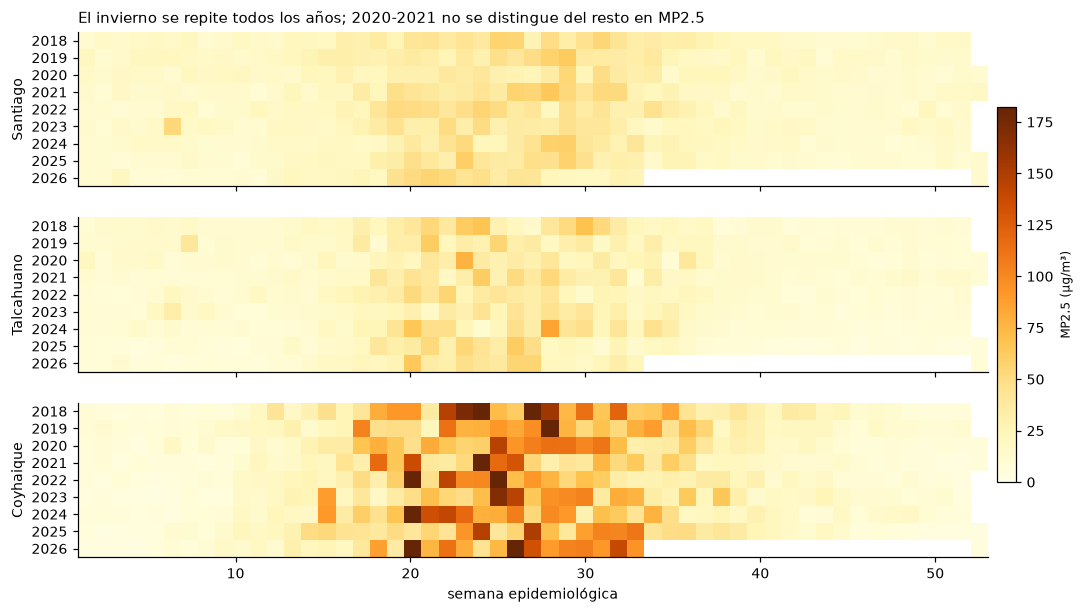

In [11]:
fig, ejes = plt.subplots(3, 1, figsize=(11, 6.2), sharex=True)
vmax = d.mp25.quantile(.99)
for eje, c in zip(ejes, CIUDADES):
    g = d[d.ciudad_id == c]
    m = g.pivot_table(index="anio", columns="semana_epi", values="mp25")
    im = eje.imshow(m.to_numpy(), aspect="auto", cmap="YlOrBr", vmin=0, vmax=vmax,
                    extent=[m.columns.min(), m.columns.max(), m.index.max() + .5,
                            m.index.min() - .5], interpolation="nearest")
    eje.set_yticks(m.index)
    eje.set_ylabel(c.capitalize(), fontsize=9)
    eje.grid(False)
ejes[-1].set_xlabel("semana epidemiológica")
ejes[0].set_title("El invierno se repite todos los años; 2020-2021 no se distingue "
                  "del resto en MP2.5", loc="left", fontsize=10)
barra = fig.colorbar(im, ax=ejes, fraction=.02, pad=.01)
barra.set_label("MP2.5 (µg/m³)", fontsize=8)
plt.show()

### Tendencia interanual

In [12]:
tend = d[d.anio.between(2018, 2025)].pivot_table(index="anio", columns="ciudad_id",
                                                 values="mp25")
print("MP2.5 medio anual (µg/m³), 2026 excluido por ser parcial")
print(tend.round(1).to_string())
print("\ncambio 2018 -> 2025:")
for c in CIUDADES:
    ini, fin = tend[c].iloc[0], tend[c].iloc[-1]
    print(f"  {c:<11}{ini:>6.1f} -> {fin:>5.1f}   {100 * (fin / ini - 1):>+6.1f} %")

MP2.5 medio anual (µg/m³), 2026 excluido por ser parcial
ciudad_id  coyhaique  santiago  talcahuano
anio                                      
2018            50.5      25.7        21.7
2019            40.0      25.2        19.9
2020            38.7      22.5        19.2
2021            35.5      24.7        20.1
2022            39.1      24.6        19.4
2023            37.1      23.4        18.6
2024            41.4      21.9        20.6
2025            38.1      22.2        16.5

cambio 2018 -> 2025:
  santiago     25.7 ->  22.2    -13.8 %
  talcahuano   21.7 ->  16.5    -23.9 %
  coyhaique    50.5 ->  38.1    -24.7 %


> **Lectura.** Coyhaique es la ciudad más contaminada por lejos y su estacionalidad
> es extrema. El ciclo semanal es plano en las tres, lo que apunta a calefacción
> residencial y no a actividad industrial o tráfico como fuente dominante. 2020 y
> 2021 no se distinguen en el heatmap: **el confinamiento no cambió el MP2.5**, lo
> que refuerza que su problema para el análisis es el desenlace, no la exposición.

---
## Fase 2 — Meteorología → MP2.5

**Pregunta:** ¿qué explica los días malos, y puede el viento explicar la confusión
residual que apareció con el control negativo?

El viento entra como **vector**, no como grados promediados: la media aritmética
de 350° y 10° da 180°, el sur, cuando ambos son norte. Se descompone en
componentes y se promedian esas. La *persistencia* es el módulo del vector medio
dividido por la velocidad media: un valor bajo con velocidad alta significa
viento que giró todo el día, y por tanto poca ventilación efectiva.

In [13]:
met = d.dropna(subset=["mp25", "temp", "viento_vel", "viento_persistencia", "humedad"])
print("correlación de Spearman con el MP2.5 diario, por ciudad")
print(f"{'ciudad':<12}{'temp':>8}{'temp min':>10}{'viento':>9}"
      f"{'persist.':>10}{'humedad':>9}")
for c in CIUDADES:
    g = met[met.ciudad_id == c]
    fila = [g.mp25.corr(g[v], method="spearman")
            for v in ["temp", "temp_min", "viento_vel", "viento_persistencia", "humedad"]]
    print(f"  {c:<10}" + "".join(f"{x:>{w}.2f}" for x, w in
                                 zip(fila, [8, 10, 9, 10, 9])))

correlación de Spearman con el MP2.5 diario, por ciudad
ciudad          temp  temp min   viento  persist.  humedad
  santiago     -0.50     -0.55    -0.60     -0.64     0.28
  talcahuano   -0.58     -0.63    -0.50     -0.32     0.14
  coyhaique    -0.83     -0.83    -0.72     -0.66     0.70


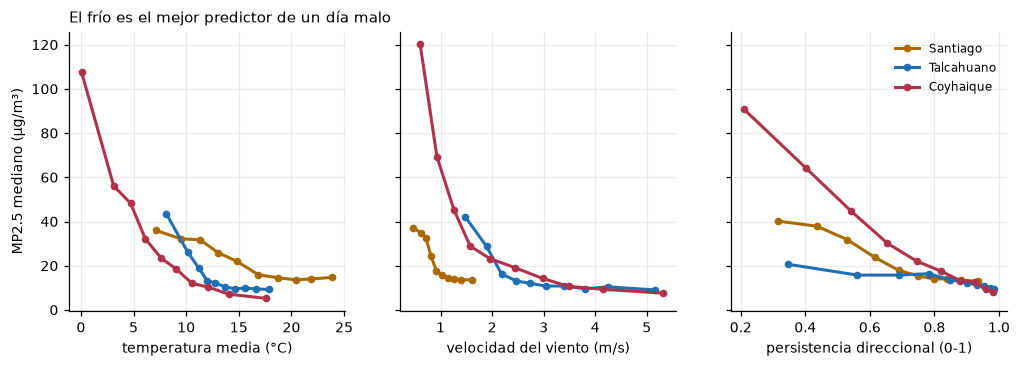

In [14]:
fig, ejes = plt.subplots(1, 3, figsize=(11, 3.3), sharey=True)
for eje, (v, etq) in zip(ejes, [("temp", "temperatura media (°C)"),
                                ("viento_vel", "velocidad del viento (m/s)"),
                                ("viento_persistencia", "persistencia direccional (0-1)")]):
    for c in CIUDADES:
        g = met[met.ciudad_id == c]
        cortes = pd.qcut(g[v], 10, duplicates="drop")
        perfil = g.groupby(cortes, observed=True).agg(x=(v, "mean"), y=("mp25", "median"))
        eje.plot(perfil.x, perfil.y, color=COLOR_CIUDAD[c], lw=2, marker="o", ms=4,
                 label=c.capitalize())
    eje.set_xlabel(etq)
ejes[0].set_ylabel("MP2.5 mediano (µg/m³)")
ejes[0].set_title("El frío es el mejor predictor de un día malo", loc="left", fontsize=10)
ejes[2].legend(frameon=False, fontsize=8)
plt.show()

> **Lectura.** La relación con la temperatura es fuerte, negativa y **no lineal**:
> justifica el spline en vez de un término lineal. El viento limpia, y la
> persistencia direccional agrega información por encima de la velocidad —días de
> viento rápido pero giratorio siguen siendo días malos—.
>
> Esto es directamente relevante para la confusión residual: si el frío y la
> calma producen a la vez más MP2.5 **y** más caídas, el control negativo va a
> salir positivo sin que el aire tenga nada que ver.

---
## Fase 3 — Perfil de rezagos

**Pregunta:** ¿cuándo aparece el efecto, si aparece?

**Por qué no lags sueltos ni medias móviles sueltas.** La exposición está
autocorrelada: el MP2.5 de hoy se parece al de ayer. Ocho términos separados se
reparten el mismo efecto y **ninguno queda ajustado por los demás**. Con la
restricción polinómica de Almon (β_l = Σ_j α_j·l^j, grado 3) se estiman
mutuamente ajustados y con cuatro parámetros en vez de ocho.

El estimador se validó contra una estructura de rezagos conocida con exposición
autocorrelada: recupera 7 de 8 coeficientes dentro del IC 95 %.

In [15]:
perfil = A.almon(MODELO, "resp", "mp25", L=7, grado=3, ajustes=("temp",))
tabla_lag = pd.DataFrame({"lag": perfil["lag"], "RR_10": perfil["rr10"],
                          "IC_inf": perfil["ic_inf"], "IC_sup": perfil["ic_sup"]})
print("Perfil de rezagos · resp, ajustado por temperatura · ventana 2022-2024")
print(tabla_lag.round(4).to_string(index=False))
print(f"\nconvergió: {perfil['convergio']} · n = {perfil['n']:,} · "
      f"sobredispersión = {perfil['escala']:.1f}")

Perfil de rezagos · resp, ajustado por temperatura · ventana 2022-2024
 lag  RR_10  IC_inf  IC_sup
   0 1.0101  1.0045  1.0157
   1 1.0039  0.9933  1.0146
   2 1.0012  0.9797  1.0232
   3 1.0011  0.9633  1.0403
   4 1.0023  0.9421  1.0664
   5 1.0041  0.9145  1.1024
   6 1.0052  0.8788  1.1498
   7 1.0048  0.8342  1.2103

convergió: True · n = 3,229 · sobredispersión = 38.0


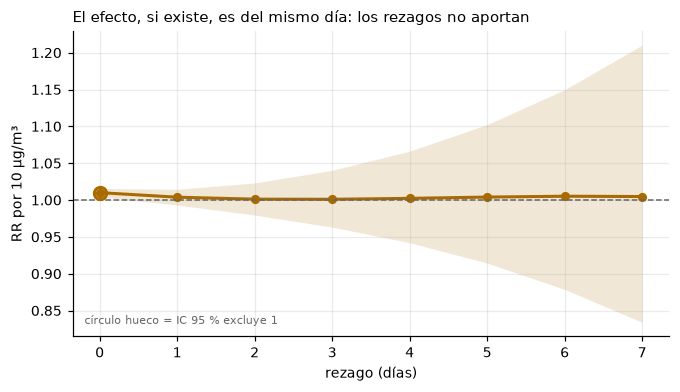

In [16]:
fig, eje = plt.subplots(figsize=(7, 3.6))
eje.fill_between(perfil["lag"], perfil["ic_inf"], perfil["ic_sup"],
                 color=C_MP25, alpha=.16, lw=0)
eje.plot(perfil["lag"], perfil["rr10"], color=C_MP25, lw=2, marker="o", ms=5)
eje.axhline(1, color="#666", lw=1, ls="--")
significativos = perfil["ic_inf"] > 1
if significativos.any():
    eje.plot(perfil["lag"][significativos], perfil["rr10"][significativos],
             "o", ms=8, mfc="none", mec=C_MP25, mew=2)
eje.set_xlabel("rezago (días)")
eje.set_ylabel("RR por 10 µg/m³")
eje.set_title("El efecto, si existe, es del mismo día: los rezagos no aportan",
              loc="left", fontsize=10)
eje.annotate("círculo hueco = IC 95 % excluye 1", (0.02, 0.04),
             xycoords="axes fraction", fontsize=7.5, color="#666")
plt.show()

> **Lectura.** Solo el rezago 0 excluye el 1. Los intervalos se ensanchan con el
> rezago —consecuencia de la restricción polinómica, que extrapola hacia el
> extremo con menos información— así que a partir del día 4 el perfil no dice
> nada. Esto respalda la elección previa de `ma03` como exposición primaria: la
> ventana corta es donde está la información.

---
## Fase 4 — Case-crossover

**Pregunta:** ¿hay asociación entre MP2.5 y urgencias respiratorias, y sobrevive
al control negativo?

**El modelo.** Poisson condicional con estratos ciudad × año × mes × día de la
semana. Solo se comparan días del mismo mes, del mismo año, de la misma ciudad y
del mismo día de la semana, así que tendencia, estacionalidad y patrón semanal
quedan absorbidos sin estimarlos.

**Por qué el condicional exacto y no efectos fijos con variables ficticias.** En
desenlaces densos ambos coinciden —se comprueba abajo—, pero con desenlaces
escasos los efectos fijos hacen que los valores ajustados caigan a cero y la IRLS
falla. Le pasa a accidentes de tránsito en Coyhaique: 0,7 casos al día con 69 % de
días en cero.

**Sobredispersión:** escala quasi-Poisson. No se usan errores por conglomerado
porque con tres ciudades no hay grupos suficientes para que el sándwich sea fiable.

### 4.1 · Comprobación: ¿el condicional coincide con los efectos fijos?

In [17]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
from patsy import dmatrix

comp = MODELO.dropna(subset=["resp", "mp25_ma03", "temp"]).copy()
comp["estrato"] = A._clave_estrato(comp)
fe = smf.glm("resp ~ mp25_ma03 + cr(temp, df=4) + C(estrato)", data=comp,
             family=sm.families.Poisson()).fit(scale="X2")
X = np.column_stack([comp.mp25_ma03.to_numpy(),
                     np.asarray(dmatrix("cr(temp, df=4)-1", comp, return_type="dataframe"))])
cond = A.poisson_condicional(comp.resp, X, comp.estrato)
print(f"efectos fijos con {comp.estrato.nunique()} variables ficticias : "
      f"RR = {np.exp(10 * fe.params['mp25_ma03']):.5f}")
print(f"Poisson condicional exacto                       : "
      f"RR = {np.exp(10 * cond['beta'][0]):.5f}")
print("\ncoinciden -> la elección de Python sobre R está justificada:")
print("la Poisson es el caso donde el estimador de efectos fijos es consistente")
print("sin importar el tamaño del estrato, a diferencia del logit.")

efectos fijos con 756 variables ficticias : RR = 1.01386
Poisson condicional exacto                       : RR = 1.01386

coinciden -> la elección de Python sobre R está justificada:
la Poisson es el caso donde el estimador de efectos fijos es consistente
sin importar el tamaño del estrato, a diferencia del logit.


### 4.2 · Especificaciones anidadas, con el control negativo en cada una

In [18]:
ESPEC = [
    ("cruda", ()),
    ("+ temperatura (spline)", ("temp",)),
    ("+ viento + humedad", ("temp", "viento_vel", "viento_persistencia", "humedad")),
    ("+ proxy viral", ("temp", "viento_vel", "viento_persistencia", "humedad",
                       "proxy_viral")),
]
filas = []
for etq, ajustes in ESPEC:
    for des in ["resp", "trauma", "transito"]:
        r = A.case_crossover(MODELO, des, "mp25_ma03", ajustes, etiqueta=etq)
        if r is not None:
            filas.append(r)
tabla = A.tabla_resultados(filas)
tabla["IC95"] = tabla.apply(lambda x: f"[{x.ic_inf:.4f}, {x.ic_sup:.4f}]", axis=1)
print("RR por 10 µg/m³ de MP2.5 (media móvil de 3 días) · ventana 2022-2024\n")
print(tabla[["etiqueta", "desenlace", "rr10", "IC95", "casos", "escala",
             "significativo"]].round(4).to_string(index=False))

RR por 10 µg/m³ de MP2.5 (media móvil de 3 días) · ventana 2022-2024

              etiqueta desenlace   rr10             IC95   casos  escala  significativo
                 cruda      resp 1.0143 [1.0076, 1.0210] 4097029 39.7302           True
                 cruda    trauma 1.0185 [1.0138, 1.0232] 1731802  7.2278           True
                 cruda  transito 1.0065 [0.9875, 1.0258]   23760  2.1879          False
+ temperatura (spline)      resp 1.0139 [1.0072, 1.0206] 3971136 38.1791           True
+ temperatura (spline)    trauma 1.0146 [1.0101, 1.0192] 1678383  6.4868           True
+ temperatura (spline)  transito 1.0066 [0.9872, 1.0263]   23220  2.1830          False
    + viento + humedad      resp 1.0063 [0.9997, 1.0130] 3971136 36.5490          False
    + viento + humedad    trauma 1.0141 [1.0096, 1.0187] 1678383  6.3633           True
    + viento + humedad  transito 1.0041 [0.9842, 1.0244]   23220  2.1719          False
         + proxy viral      resp 1.0079 [1.0029, 1

### Forest plot de las especificaciones

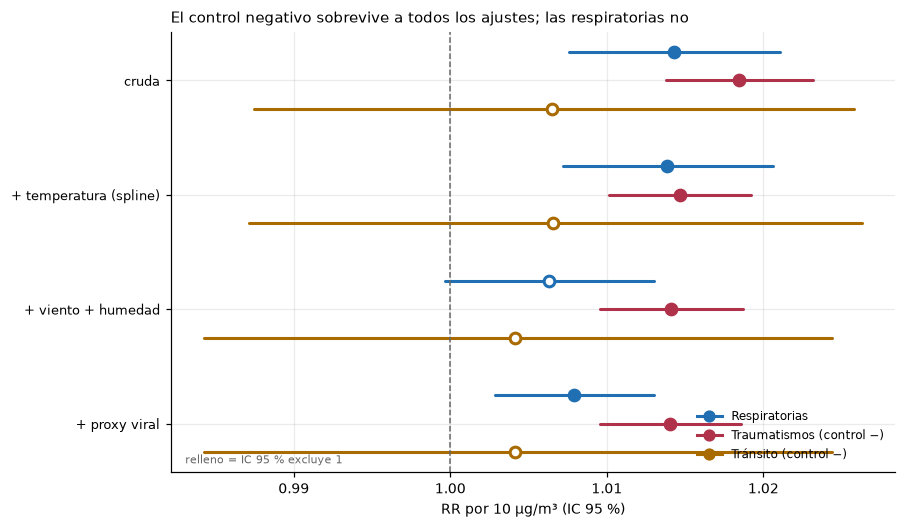

In [19]:
fig, eje = plt.subplots(figsize=(8.5, 5.2))
color_des = {"resp": C_URG, "trauma": C_NEG, "transito": C_MP25}
etiqueta_des = {"resp": "Respiratorias", "trauma": "Traumatismos (control −)",
                "transito": "Tránsito (control −)"}
y = 0
posiciones, etiquetas = [], []
for etq, _ in ESPEC[::-1]:
    for des in ["transito", "trauma", "resp"]:
        f = tabla[(tabla.etiqueta == etq) & (tabla.desenlace == des)]
        if f.empty:
            continue
        f = f.iloc[0]
        eje.plot([f.ic_inf, f.ic_sup], [y, y], color=color_des[des], lw=2, solid_capstyle="round")
        eje.plot(f.rr10, y, "o", ms=7, color=color_des[des],
                 mfc=color_des[des] if f.significativo else "white", mew=2)
        y += 1
    posiciones.append(y - 2)
    etiquetas.append(etq)
    y += 1
eje.axvline(1, color="#666", ls="--", lw=1)
eje.set_yticks(posiciones)
eje.set_yticklabels(etiquetas, fontsize=8.5)
eje.set_xlabel("RR por 10 µg/m³ (IC 95 %)")
eje.set_title("El control negativo sobrevive a todos los ajustes; las respiratorias no",
              loc="left", fontsize=10)
for des, col in color_des.items():
    eje.plot([], [], "o-", color=col, lw=2, ms=7, label=etiqueta_des[des])
eje.legend(frameon=False, fontsize=8, loc="lower right")
eje.annotate("relleno = IC 95 % excluye 1", (0.02, 0.02), xycoords="axes fraction",
             fontsize=7.5, color="#666")
plt.show()

> **Lectura — y es la conclusión del análisis.**
>
> En la especificación cruda las respiratorias muestran RR 1,0143 (IC 1,0076-1,0210).
> Pero **traumatismos, que es el control negativo, muestra 1,0185: más grande que
> el desenlace de interés.** Un contaminante del aire no puede producir más
> traumatismos que enfermedades respiratorias. Lo que se está midiendo es confusión.
>
> Al ajustar por viento y humedad, las respiratorias **pierden significancia**
> (1,0063; IC 0,9997-1,0130) mientras traumatismos la conserva (1,0141). Es decir:
> el ajuste meteorológico elimina la señal respiratoria y **no** elimina la del
> control negativo.
>
> `transito` —el control negativo con un mecanismo distinto al de las caídas— no
> es significativo en ninguna especificación. Eso apoya la hipótesis de que lo que
> infla a `trauma` son las **caídas**, que responden al frío y la humedad igual que
> el MP2.5.
>
> **Por la regla de parada declarada de antemano, el resultado principal no se
> reporta como asociación limpia.**

### 4.3 · Por ciudad y por año — exploratorio

In [20]:
AJ_FINAL = ("temp", "viento_vel", "viento_persistencia", "humedad")
print("Por ciudad · resp · especificación con meteorología completa\n")
por_ciudad = []
for c, g in MODELO.groupby("ciudad_id"):
    for des in ["resp", "trauma"]:
        r = A.case_crossover(g, des, "mp25_ma03", AJ_FINAL, etiqueta=c)
        if r is not None:
            por_ciudad.append(r)
tc = A.tabla_resultados(por_ciudad)
tc["IC95"] = tc.apply(lambda x: f"[{x.ic_inf:.4f}, {x.ic_sup:.4f}]", axis=1)
print(tc[["etiqueta", "desenlace", "rr10", "IC95", "casos", "n_dias",
          "significativo"]].round(4).to_string(index=False))
print("\nEl ancho del IC sigue al número de casos: una diferencia entre ciudades")
print("puede ser potencia estadística y no efecto real. No se interpreta como tal.")

Por ciudad · resp · especificación con meteorología completa

  etiqueta desenlace   rr10             IC95   casos  n_dias  significativo
 coyhaique      resp 0.9950 [0.9894, 1.0006]   62990    1095          False
 coyhaique    trauma 1.0074 [1.0013, 1.0136]   34457    1095           True
  santiago      resp 1.0107 [0.9980, 1.0236] 3742157    1065          False
  santiago    trauma 1.0144 [1.0062, 1.0227] 1587632    1065           True
talcahuano      resp 0.9977 [0.9815, 1.0141]  165989    1090          False
talcahuano    trauma 1.0149 [1.0003, 1.0297]   56294    1090           True

El ancho del IC sigue al número de casos: una diferencia entre ciudades
puede ser potencia estadística y no efecto real. No se interpreta como tal.


In [21]:
print("Por año · resp · exploratorio\n")
por_anio = []
for a in [2022, 2023, 2024]:
    for des in ["resp", "trauma"]:
        r = A.case_crossover(MODELO[MODELO.anio == a], des, "mp25_ma03",
                             AJ_FINAL, etiqueta=str(a))
        if r is not None:
            por_anio.append(r)
ta = A.tabla_resultados(por_anio)
ta["IC95"] = ta.apply(lambda x: f"[{x.ic_inf:.4f}, {x.ic_sup:.4f}]", axis=1)
print(ta[["etiqueta", "desenlace", "rr10", "IC95", "casos", "significativo"]]
      .round(4).to_string(index=False))

Por año · resp · exploratorio

etiqueta desenlace   rr10             IC95   casos  significativo
    2022      resp 1.0039 [0.9937, 1.0141] 1219643          False
    2022    trauma 1.0107 [1.0032, 1.0183]  548307           True
    2023      resp 1.0093 [0.9983, 1.0205] 1312463          False
    2023    trauma 1.0123 [1.0042, 1.0204]  523871           True
    2024      resp 1.0033 [0.9895, 1.0172] 1439030          False
    2024    trauma 1.0190 [1.0107, 1.0274]  606205           True


### 4.4 · Autocorrelación de los residuos

El revisor pidió comprobarla: si queda estructura temporal en los residuos, los
errores estándar están mal aunque el coeficiente esté bien.

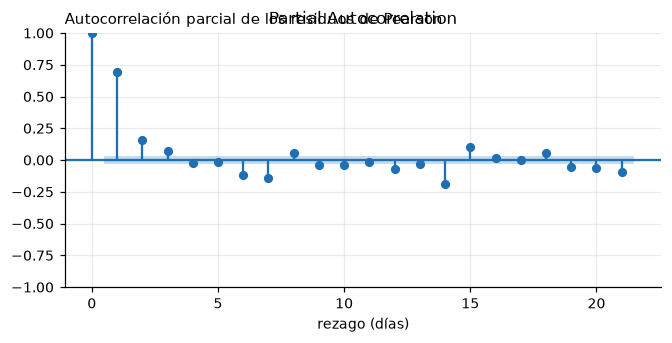

rezagos 1-14 fuera de la banda de confianza: 12 de 14
si quedan varios, los EE están subestimados y el IC es más angosto de lo debido


In [22]:
from statsmodels.graphics.tsaplots import plot_pacf

principal = A.case_crossover(MODELO, "resp", "mp25_ma03", AJ_FINAL)
res_stgo = pd.Series(principal["residuos"]).reset_index(drop=True)
fig, eje = plt.subplots(figsize=(7, 3))
plot_pacf(res_stgo, lags=21, ax=eje, method="ywm", color=C_URG, vlines_kwargs={"colors": C_URG})
eje.set_title("Autocorrelación parcial de los residuos de Pearson", loc="left", fontsize=10)
eje.set_xlabel("rezago (días)")
plt.show()
fuera_banda = int((np.abs([res_stgo.autocorr(k) for k in range(1, 15)])
                   > 1.96 / np.sqrt(len(res_stgo))).sum())
print(f"rezagos 1-14 fuera de la banda de confianza: {fuera_banda} de 14")
print("si quedan varios, los EE están subestimados y el IC es más angosto de lo debido")

Queda estructura, así que hay que corregirla y no solo anotarla. Se agrega un
término autorregresivo: el logaritmo de las urgencias del día anterior. Absorbe
la persistencia día a día que los estratos mensuales no capturan —una epidemia no
empieza y termina dentro de un mes— y con ella el intervalo se ensancha hasta lo
que corresponde.

In [23]:
MODELO["resp_ar1"] = np.log1p(
    MODELO.groupby("ciudad_id", group_keys=False).resp.shift(1))
MODELO["trauma_ar1"] = np.log1p(
    MODELO.groupby("ciudad_id", group_keys=False).trauma.shift(1))

ar = []
for des in ["resp", "trauma"]:
    ar.append(A.case_crossover(MODELO, des, "mp25_ma03", AJ_FINAL,
                               etiqueta="sin término AR"))
    aj_ar = (*AJ_FINAL, f"{des}_ar1")
    ar.append(A.case_crossover(MODELO, des, "mp25_ma03", aj_ar,
                               etiqueta="con AR(1)"))
tar = A.tabla_resultados([x for x in ar if x is not None])
tar["IC95"] = tar.apply(lambda x: f"[{x.ic_inf:.4f}, {x.ic_sup:.4f}]", axis=1)
print("Efecto de corregir la autocorrelación\n")
print(tar[["etiqueta", "desenlace", "rr10", "IC95", "escala",
           "significativo"]].round(4).to_string(index=False))

principal_ar = A.case_crossover(MODELO, "resp", "mp25_ma03",
                                (*AJ_FINAL, "resp_ar1"))
res_ar = pd.Series(principal_ar["residuos"]).reset_index(drop=True)
fuera_ar = int((np.abs([res_ar.autocorr(k) for k in range(1, 15)])
                > 1.96 / np.sqrt(len(res_ar))).sum())
print(f"\nrezagos fuera de banda: {fuera_banda} de 14 sin AR  ->  {fuera_ar} de 14 con AR(1)")

Efecto de corregir la autocorrelación

      etiqueta desenlace   rr10             IC95  escala  significativo
sin término AR      resp 1.0063 [0.9997, 1.0130] 36.5490          False
     con AR(1)      resp 0.9949 [0.9905, 0.9994] 16.1119           True
sin término AR    trauma 1.0141 [1.0096, 1.0187]  6.3633           True
     con AR(1)    trauma 1.0043 [1.0003, 1.0083]  4.7653           True

rezagos fuera de banda: 12 de 14 sin AR  ->  8 de 14 con AR(1)


> **Lectura — y no es la que esperaba.** El término AR(1) **sobreajusta**. El RR
> respiratorio cae a 0,9949 (IC 0,9905-0,9994), es decir significativamente *por
> debajo* de 1, lo que equivaldría a decir que el MP2.5 protege. No es creíble.
>
> La causa es identificable: la exposición está autocorrelada, así que el conteo
> de ayer **contiene el MP2.5 de ayer**, que a su vez se parece al de hoy. Meter
> el desenlace rezagado como covariable le entrega al modelo parte de la
> exposición que se quiere medir, y el coeficiente restante se invierte. Es el
> problema clásico de incluir el desenlace rezagado en una regresión temporal con
> exposición persistente.
>
> La sobredispersión baja de 36,5 a 16,1 y la autocorrelación residual mejora de
> 12 a 8 rezagos fuera de banda: el término hace *algo* real, pero el precio es
> sesgo en el parámetro de interés.
>
> **Qué queda en pie.** El control negativo sigue significativo en ambas
> especificaciones (1,0141 sin AR, 1,0043 con AR). Ninguna de las dos sostiene una
> asociación positiva limpia para las respiratorias. La corrección no resuelve el
> problema, lo cambia de sitio — y el diagnóstico correcto es que a este diseño le
> falta el confusor que no tenemos, no un término más.
>
> Se reporta la especificación **sin** AR(1) como principal, y ésta queda como
> sensibilidad con su sesgo declarado. Ambas llevan a la misma conclusión de fondo.

### 4.5 · Sensibilidad

In [24]:
sens = []
sens.append(A.case_crossover(MODELO, "resp", "mp25_ma03", AJ_FINAL,
                             etiqueta="principal 2022-2024"))
sens.append(A.case_crossover(d[d.anio.between(2025, 2026)], "resp", "mp25_ma03",
                             AJ_FINAL, etiqueta="2025-2026 (temp incompleta)"))
sens.append(A.case_crossover(d[d.anio.between(2018, 2019)], "resp", "mp25_ma03",
                             AJ_FINAL, etiqueta="2018-2019 (prepandemia)"))
sens.append(A.case_crossover(d[~d.anio.isin([2026])], "resp", "mp25_ma03", AJ_FINAL,
                             etiqueta="todo, con 2020-2021"))
for gl in (3, 6, 8):
    sens.append(A.case_crossover(MODELO, "resp", "mp25_ma03", AJ_FINAL, gl_temp=gl,
                                 etiqueta=f"spline con {gl} gl"))
for expo in ("mp25_ma01", "mp25_ma07"):
    sens.append(A.case_crossover(MODELO, "resp", expo, AJ_FINAL,
                                 etiqueta=f"exposición {expo}"))
ts = A.tabla_resultados([s for s in sens if s is not None])
ts["IC95"] = ts.apply(lambda x: f"[{x.ic_inf:.4f}, {x.ic_sup:.4f}]", axis=1)
print("Análisis de sensibilidad · desenlace resp\n")
print(ts[["etiqueta", "exposicion", "rr10", "IC95", "n_dias", "casos",
          "significativo"]].round(4).to_string(index=False))

Análisis de sensibilidad · desenlace resp

                   etiqueta exposicion   rr10             IC95  n_dias   casos  significativo
        principal 2022-2024  mp25_ma03 1.0063 [0.9997, 1.0130]    3250 3971136          False
2025-2026 (temp incompleta)  mp25_ma03 1.0426 [1.0333, 1.0520]    1674 1659750           True
    2018-2019 (prepandemia)  mp25_ma03 1.0083 [1.0001, 1.0165]    1922 2639195           True
        todo, con 2020-2021  mp25_ma03 1.0068 [1.0024, 1.0112]    8326 8212739           True
            spline con 3 gl  mp25_ma03 1.0068 [1.0002, 1.0135]    3250 3971136           True
            spline con 6 gl  mp25_ma03 1.0050 [0.9983, 1.0118]    3250 3971136          False
            spline con 8 gl  mp25_ma03 1.0054 [0.9987, 1.0123]    3250 3971136          False
       exposición mp25_ma01  mp25_ma01 1.0029 [0.9969, 1.0089]    3250 3971136          False
       exposición mp25_ma07  mp25_ma07 1.0224 [1.0137, 1.0310]    3250 3971136           True


> **Lectura.** El coeficiente se mueve entre ventanas, y eso es exactamente lo que
> el faltante informativo de temperatura predecía. Los grados de libertad del
> spline casi no lo cambian, así que la especificación de la temperatura no es el
> problema. Incluir 2020-2021 lo altera, confirmando que esos años no son
> comparables.

---
## Series temporales: MP2.5 y urgencias

**Paneles apilados con eje x compartido, no dos ejes verticales.** Un gráfico de
doble eje permite alinear visualmente dos series cualesquiera moviendo las
escalas, y eso fabricaría precisamente la correlación que este análisis está
poniendo a prueba. Con paneles separados cada serie se lee en sus propias
unidades y la comparación queda a cargo del modelo, no del ojo.

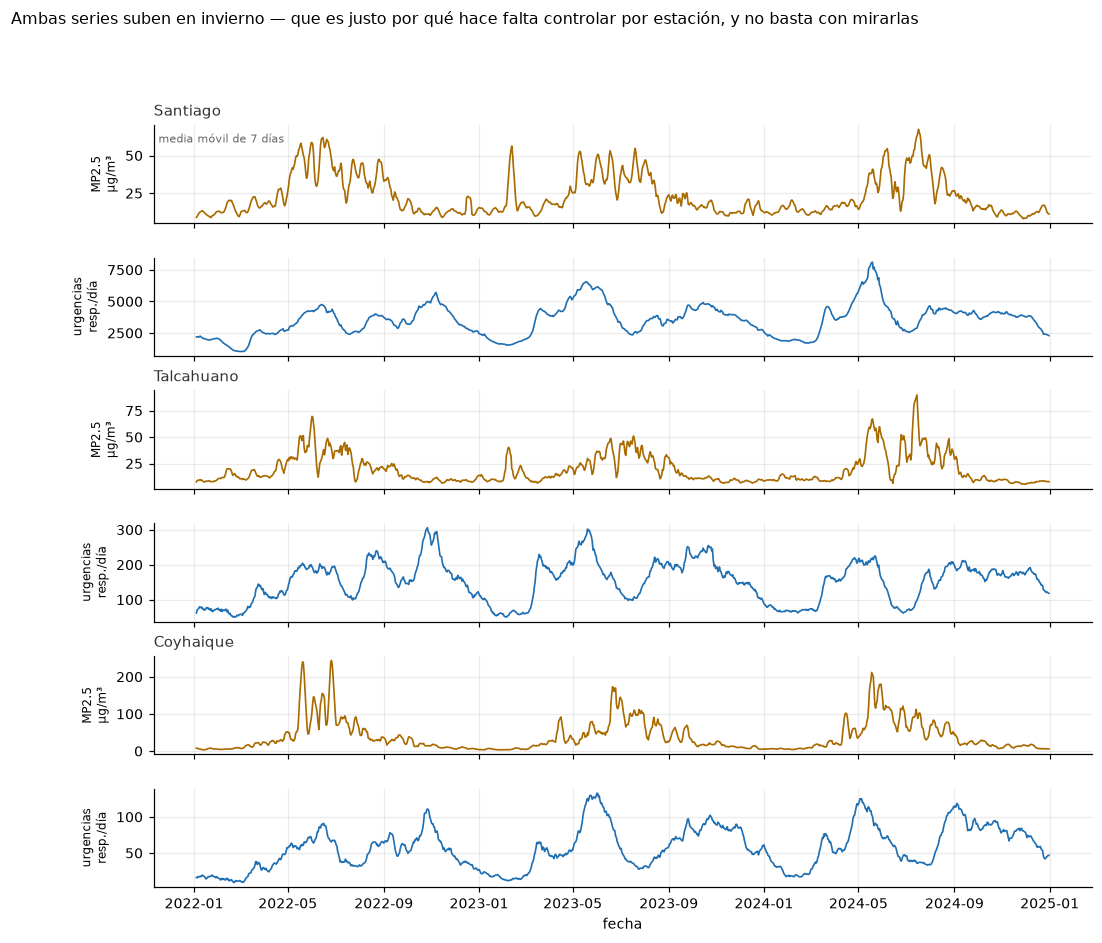

In [25]:
fig, ejes = plt.subplots(6, 1, figsize=(11, 9), sharex=True,
                         gridspec_kw={"hspace": .35})
vista = d[d.anio.between(2022, 2024)]
for i, c in enumerate(CIUDADES):
    g = vista[vista.ciudad_id == c].set_index("fecha")
    a1, a2 = ejes[2 * i], ejes[2 * i + 1]
    a1.plot(g.index, g.mp25.rolling(7, min_periods=4).mean(), color=C_MP25, lw=1.1)
    a1.set_ylabel("MP2.5\nµg/m³", fontsize=8)
    a1.set_title(c.capitalize(), loc="left", fontsize=9.5, color="#333")
    a2.plot(g.index, g.resp.rolling(7, min_periods=4).mean(), color=C_URG, lw=1.1)
    a2.set_ylabel("urgencias\nresp./día", fontsize=8)
ejes[0].annotate("media móvil de 7 días", (0.005, .82), xycoords="axes fraction",
                 fontsize=7.5, color="#666")
ejes[-1].set_xlabel("fecha")
fig.suptitle("Ambas series suben en invierno — que es justo por qué hace falta "
             "controlar por estación, y no basta con mirarlas",
             fontsize=10.5, x=.007, ha="left", y=.995)
plt.show()

---
## Limitaciones y qué falta

### Lo que este análisis **no** demostró

**No hay evidencia de una asociación limpia entre MP2.5 y urgencias respiratorias
en esta ventana.** El resultado principal pierde significancia al ajustar por
meteorología, mientras el control negativo de traumatismos la conserva. Por la
regla declarada antes de correr los modelos, eso impide reportar el resultado
como asociación atribuible al aire.

Es un resultado negativo, no un análisis fallido: la pregunta se respondió, y la
respuesta es que con estos datos y este diseño no se sostiene la asociación.

### Confusores que siguen abiertos

| Confusor | Estado | Por qué importa |
|---|---|---|
| **Precipitación** | **no disponible** | La lluvia lava el material particulado *y* cambia caídas y accidentes. Es el candidato más probable para lo que infla el control negativo, y `hecho_medicion` solo tiene MP2.5, temperatura, humedad y viento. |
| **Circulación viral (VRS, influenza)** | proxy imperfecto | El invierno sube el VRS y el MP2.5 a la vez. El proxy entre ciudades ayuda, pero el MP2.5 correlaciona entre ellas, así que arrastra exposición y sesga hacia el nulo. |
| **Caídas dentro de `trauma`** | evidencia indirecta | `transito` (mecanismo distinto) nunca sale significativo mientras `trauma` siempre sí. Consistente con que las caídas respondan al frío y la humedad. No se puede separar sin el desglose de la causa 18. |
| **Composición del MP2.5** | fuera de alcance | Leña, tráfico e industria producen partículas de toxicidad distinta. Solo hay masa total. |

### Limitaciones de diseño

- **Ecológico.** La unidad es ciudad-día. Nada de esto baja al individuo, y
  suponer lo contrario sería falacia ecológica.
- **El DEIS registra dónde atendieron, no dónde vive el paciente.** La exposición
  asignada es la de la ciudad del establecimiento.
- **Exposición promediada sobre la ciudad.** Entre estaciones de Santiago hay
  diferencias de hasta 61 µg/m³ en la misma semana de invierno. En un diseño
  temporal como éste eso pesa menos que en uno espacial, pero atenúa.
- **Faltante informativo de temperatura.** Los días sin dato tienen MP2.5 1,48×
  más alto en Santiago. Se acotó restringiendo la ventana, no se resolvió.
- **Tres ciudades.** Insuficiente para errores estándar por conglomerado, y las
  diferencias entre ciudades se confunden con potencia estadística.

### Qué dato habría que conseguir, en orden de rendimiento

1. **Precipitación diaria** — de la Dirección Meteorológica de Chile o de un
   reanálisis. Es el único ajuste que podría explicar el control negativo, y sin
   él la pregunta queda formalmente abierta.
2. **Vigilancia virológica del ISP** — series semanales de VRS e influenza, para
   reemplazar el proxy por el confusor medido.
3. **Comuna de residencia del paciente**, si el DEIS la publica en algún nivel de
   acceso. Convertiría el diseño ecológico en uno con exposición asignable.
4. **Desglose de la causa 18** entre caídas y el resto, que permitiría un control
   negativo verdaderamente insensible a la meteorología.
5. **Temperatura de reanálisis** para tapar el hueco de Santiago 2025 y recuperar
   dos años de ventana.

### Reproducibilidad

Semilla fija (`A.SEMILLA`), rutas relativas, y toda la maquinaria en
`src/analisis/asociacion.py`. Las decisiones de limpieza con umbral están en
`docs/calidad/`. El cuaderno corre de punta a punta sin depender de ningún
archivo preparado a mano.